<a href="https://colab.research.google.com/github/AlinaUK/Alina_Business_Card/blob/main/ELECTRIC_VEHICLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Electric Vehicle Population Analysis**

Student ID 14013675




# **Abstract**

In this coursework, I analyzed the electric vehicle (EV) registrations dataset from Washington State. I used Python libraries like pandas, matplotlib, seaborn, and scikit-learn to clearly explore trends, vehicle popularity, EV types, and distribution. I learned important patterns, especially that Tesla dominates the market and EV use is increasing fast.

# **Data Acquisition**
In this step, we will start by loading the dataset. I used an openly available dataset from Kaggle. The dataset I used is downloaded as a CSV file and contains information specifically about electric vehicles registered in Washington State, USA

Dataset link: [Electric Vehicle Population Data](https://www.kaggle.com/datasets/yashdogra/ev-bhebic-c/)

In [2]:
# First we import the libraries we will need for our project:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset into a DataFrame
df = pd.read_csv('/content/Electric Vehicle Population Data.csv')

# Display the first 10 rows
df.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,2T3YL4DV0E,King,Bellevue,WA,98005,2014.0,TOYOTA,RAV4,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,103.0,0.0,41.0,186450183.0,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EB6K,King,Bothell,WA,98011,2019.0,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,1.0,478093654.0,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,5UX43EU02S,Thurston,Olympia,WA,98502,2025.0,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,0.0,35.0,274800718.0,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
3,JTMAB3FV5R,Thurston,Olympia,WA,98513,2024.0,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,260758165.0,POINT (-122.81754 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE8M,Yakima,Selah,WA,98942,2021.0,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,236581355.0,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
5,3C3CFFGE1G,Thurston,Olympia,WA,98501,2016.0,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,22.0,294762219.0,POINT (-122.89166 47.03956),PUGET SOUND ENERGY INC,5.306701e+10
6,5YJ3E1EA4J,Snohomish,Marysville,WA,98271,2018.0,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,39.0,270125096.0,POINT (-122.1677 48.11026),PUGET SOUND ENERGY INC,5.306105e+10
7,5YJ3E1EA3K,King,Seattle,WA,98102,2019.0,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,43.0,238776492.0,POINT (-122.32427 47.63433),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
8,1N4AZ0CP5E,Thurston,Yelm,WA,98597,2014.0,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,2.0,257246118.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
9,5YJSA1S25F,Thurston,Yelm,WA,98597,2015.0,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,2.0,161974606.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


# **Data Understanding**

The second step was to understand the data which has been downloaded. The dataset columns were described as below:
MAKE - Manufacturer of the electric vehicle (Tesla, Nissan, etc.)
MODEL - Specific vehicle model name (Model S, Leaf, Bolt, etc.)
MODEL_YEAR - Year the vehicle model was manufactured
ELECTRIC_RANGE - Estimated miles the vehicle can travel on a single charge
EV_TYPE - Classification as Battery Electric Vehicle (BEV) or Plug-in Hybrid Electric Vehicle (PHEV)
STATE - Geographic location where the vehicle is registered
COUNTY - Specific county within the state where the vehicle is registered
REGISTRATION_COUNT - Number of vehicles of this make/model registered in the specified location

I  checked the structure, columns, and missing values to understand data better:

In [3]:
# Shows the first 10 rows:
df.head(10)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,2T3YL4DV0E,King,Bellevue,WA,98005,2014,TOYOTA,RAV4,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,103.0,0.0,41.0,186450183,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EB6K,King,Bothell,WA,98011,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,1.0,478093654,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,5UX43EU02S,Thurston,Olympia,WA,98502,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,0.0,35.0,274800718,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
3,JTMAB3FV5R,Thurston,Olympia,WA,98513,2024,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,260758165,POINT (-122.81754 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE8M,Yakima,Selah,WA,98942,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,236581355,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
5,3C3CFFGE1G,Thurston,Olympia,WA,98501,2016,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,22.0,294762219,POINT (-122.89166 47.03956),PUGET SOUND ENERGY INC,5.306701e+10
6,5YJ3E1EA4J,Snohomish,Marysville,WA,98271,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,0.0,39.0,270125096,POINT (-122.1677 48.11026),PUGET SOUND ENERGY INC,5.306105e+10
7,5YJ3E1EA3K,King,Seattle,WA,98102,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,43.0,238776492,POINT (-122.32427 47.63433),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
8,1N4AZ0CP5E,Thurston,Yelm,WA,98597,2014,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84.0,0.0,2.0,257246118,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
9,5YJSA1S25F,Thurston,Yelm,WA,98597,2015,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,0.0,2.0,161974606,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10


In [4]:
# Check data types, columns, and how many values are missing:
df.columns



Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Base MSRP', 'Legislative District', 'DOL Vehicle ID',
       'Vehicle Location', 'Electric Utility', '2020 Census Tract'],
      dtype='object')

In [6]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156525 entries, 0 to 156524
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         156525 non-null  object 
 1   County                                             156525 non-null  object 
 2   City                                               156525 non-null  object 
 3   State                                              156525 non-null  object 
 4   Postal Code                                        156525 non-null  int64  
 5   Model Year                                         156524 non-null  float64
 6   Make                                               156524 non-null  object 
 7   Model                                              156524 non-null  object 
 8   Electric Vehicle Type                              156524 non-null  object

This part helps me understand what data I have to work with.
The data has multiple text and numeric columns. I saw that some columns like 'Base MSRP' had unusual values (like many zeros).

**Data Exploration**

I examined the basic statistics of the dataset using df.describe() to get an understanding of the distribution of numeric values, particularly focusing on the Electric Range column.

In [5]:
df.describe()




,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,156525.000000,156524.000000,156503.000000,156503.000000,156422.000000,1.565240e+05,1.565240e+05
mean,98197.450267,2021.351767,47.251733,807.856175,30.466264,2.340687e+08,5.301828e+10
std,1491.243434,2.982183,84.557284,7363.955603,14.678062,6.894011e+07,8.616862e+08
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.101001e+09
25%,98042.000000,2020.000000,0.000000,0.000000,18.000000,2.028228e+08,5.303301e+10
50%,98115.000000,2023.000000,0.000000,0.000000,34.000000,2.509773e+08,5.303303e+10
75%,98312.000000,2023.000000,39.000000,0.000000,43.000000,2.683619e+08,5.303509e+10
max,99403.000000,2025.000000,337.000000,845000.000000,49.000000,4.789259e+08,5.602100e+10


In [4]:
df.tail(7)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
156518,5YJYGDEE1M,King,Seattle,WA,98117,2021.0,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,36.0,154261565.0,POINT (-122.38418 47.70044),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
156519,JTMAB3FV8R,Grays Harbor,Copalis Beach,WA,98535,2024.0,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,24.0,270848868.0,POINT (-124.16705 47.11487),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF G...,5.302700e+10
156520,7SAYGAEE1P,Snohomish,Mountlake Terrace,WA,98043,2023.0,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,1.0,227532994.0,POINT (-122.31111 47.78803),PUGET SOUND ENERGY INC,5.306105e+10
156521,5YJSA1E22J,King,Woodinville,WA,98072,2018.0,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,249.0,0.0,45.0,281613727.0,POINT (-122.15545 47.75448),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
156522,JTDKARFP5K,Thurston,Lacey,WA,98503,2019.0,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25.0,0.0,22.0,474517963.0,POINT (-122.82324 47.04437),PUGET SOUND ENERGY INC,5.306701e+10
156523,5YJXCBE28L,Pierce,Graham,WA,98338,2020.0,TESLA,MODEL X,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,293.0,0.0,2.0,104323348.0,POINT (-122.29477 47.05703),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
156524,JM3KKEHA9R,Spokane,Spokane,WA,99223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print(np.shape(df))

(156525, 17)


# **Data Cleaning**

Improving the quality of our electric vehicle data by cleaning is the fourth step in our process. One important method of cleaning is identifying and removing outliers, which helps reduce errors in our analysis.

We compare visualizations—like boxplots and scatter plots—with summary statistics from the df.describe() table to decide which values are outliers. For example, when we look at the Electric Range column, the summary statistics might show that 75% of the vehicles have an electric range below a certain value (say, 150 miles). The boxplot and scatter plot of Electric Range clearly show that most values fall below this threshold, while a few extreme values lie well above it. Removing these extreme outliers can help reduce error and improve our overall data quality.

That rule and procedure applied to the rest of the remaining columns as well. The scripts are shown
below which were used to clean the data.

In [67]:
# Check missing values
df.isnull().sum()


,0
VIN (1-10),0
County,4
City,4
State,0
Postal Code,4
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,0


In [75]:
import pandas as pd  # Loads pandas library to work with data tables

# Drops rows missing any of these location fields
df = df.dropna(subset=['County', 'City', 'Postal Code', 'Electric Utility', '2020 Census Tract'])

# Fills missing Vehicle Location with "Unknown"
df['Vehicle Location'] = df['Vehicle Location'].fillna('Unknown')

# Fills missing Electric Range with median for same Make/Model
df['Electric Range'] = df.groupby(['Make', 'Model'])['Electric Range'].transform(lambda x: x.fillna(x.median()))

# Fills missing Base MSRP with median for same Make/Model
df['Base MSRP'] = df.groupby(['Make', 'Model'])['Base MSRP'].transform(lambda x: x.fillna(x.median()))

# Fills any leftover missing Electric Range with overall median
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].median())

# Fills any leftover missing Base MSRP with overall median
df['Base MSRP'] = df['Base MSRP'].fillna(df['Base MSRP'].median())

# Fills missing Legislative District with "Not Assigned"
df['Legislative District'] = df['Legislative District'].fillna('Not Assigned')

# Prints count of missing values to check cleaning worked
print(df.isnull().sum())

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


A check for missing values revealed that most columns are complete, but some have gaps: 4 missing entries in location-related fields (County, City, Postal Code, Electric Utility, 2020 Census Tract), 11 in Vehicle Location, 27 in Electric Range and Base MSRP, and 481 in Legislative District. Cleaning this data involves dropping or imputing these missing values based on their importance to the analysis.

# **Data Exploration**
Now, I want to find some interesting facts from the data.

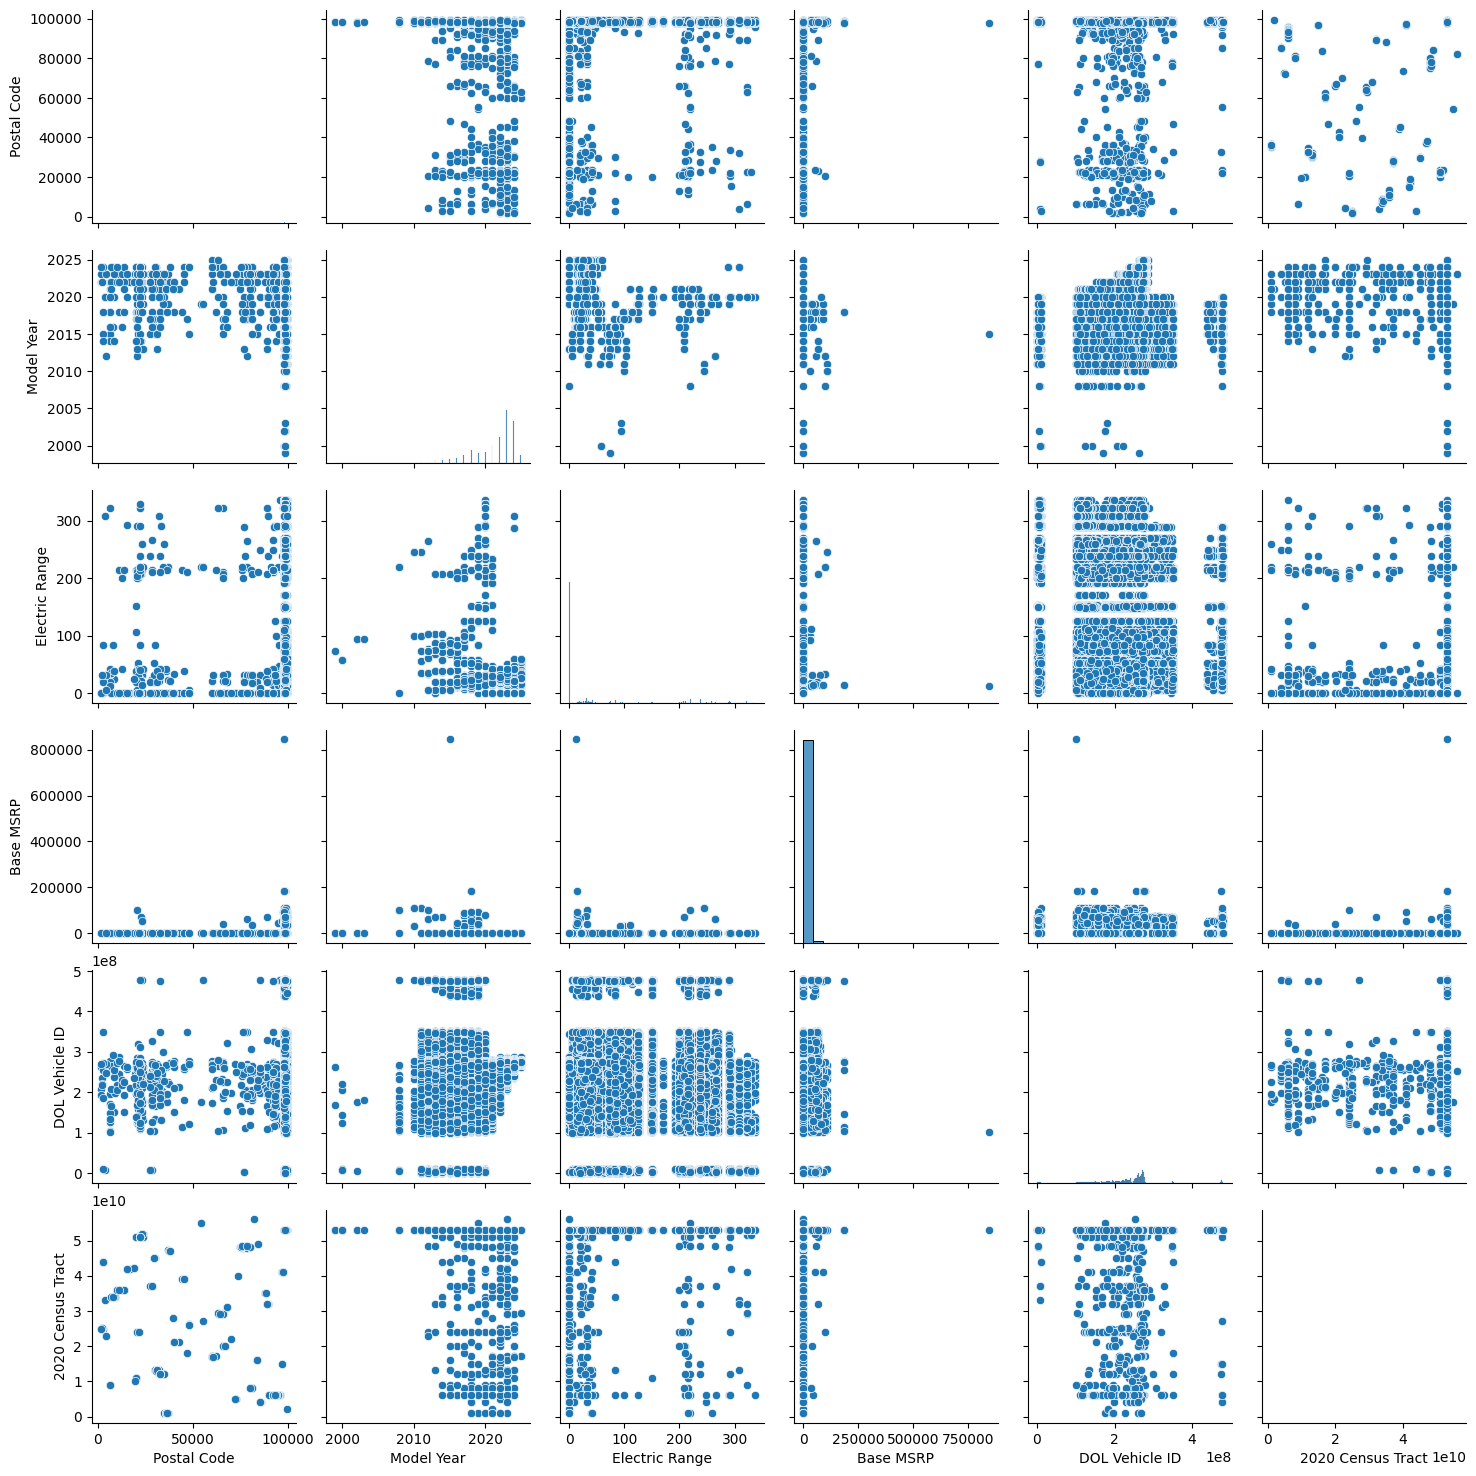

In [76]:
sns.pairplot(df)

The pair plot reveals that the dataset contains numerical variables like "Postal Code," "Model Year," "Electric Range," "Base MSRP," "DOL Vehicle ID," and "2020 Census Tract," with newer models (post-2015) showing higher electric ranges. However, "Base MSRP" has many 0 values, suggesting potential data issues, and relationships with other variables are unclear due to sparse or outlier-heavy data. Location-based columns ("Postal Code" and "2020 Census Tract") show expected correlations, while "DOL Vehicle ID" lacks meaningful patterns. Further cleaning and analysis, especially of "Base MSRP," are recommended.

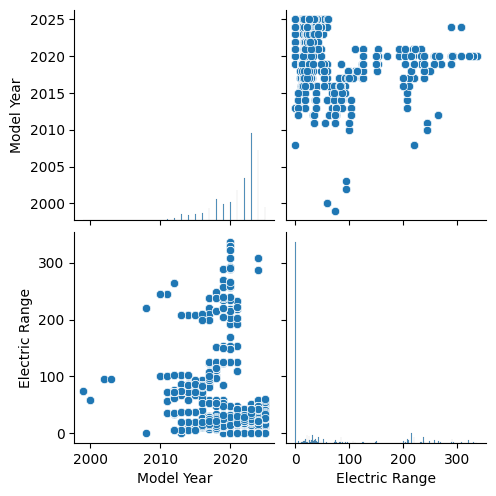

In [80]:
sns.pairplot(df[['Model Year', 'Electric Range', 'Legislative District']])
plt.show()

The pair plot highlights a clear trend: newer vehicles (post-2015) generally have higher electric ranges, with many reaching 200–300 miles, while older models (pre-2010) are mostly below 100 miles. "Legislative District" doesn’t appear in the plot, likely due to its non-numeric values ("Not Assigned" after cleaning). This suggests focusing on "Model Year" and "Electric Range" for further analysis of electric vehicle trends.

<class 'pandas.core.frame.DataFrame'>
Index: 232226 entries, 0 to 232229
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         232226 non-null  object 
 1   County                                             232226 non-null  object 
 2   City                                               232226 non-null  object 
 3   State                                              232226 non-null  object 
 4   Postal Code                                        232226 non-null  float64
 5   Model Year                                         232226 non-null  int64  
 6   Make                                               232226 non-null  object 
 7   Model                                              232226 non-null  object 
 8   Electric Vehicle Type                              232226 non-null  object 
 9 

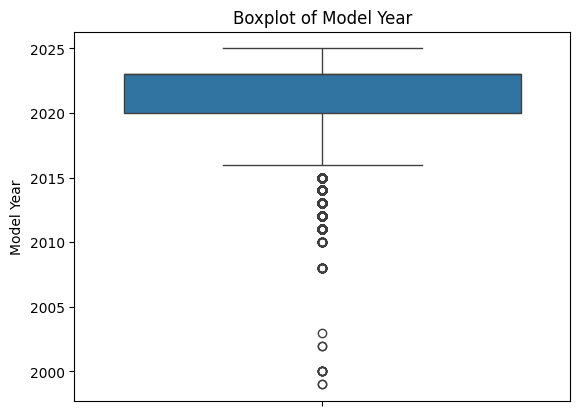

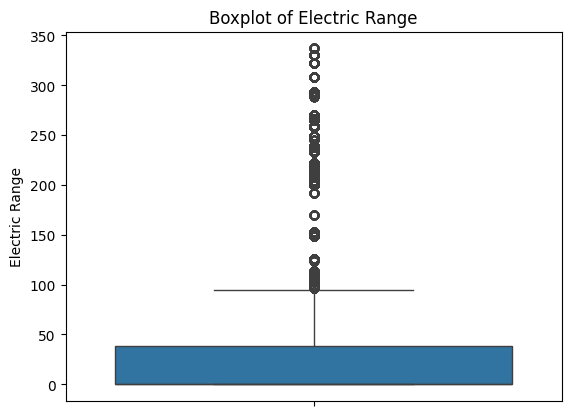

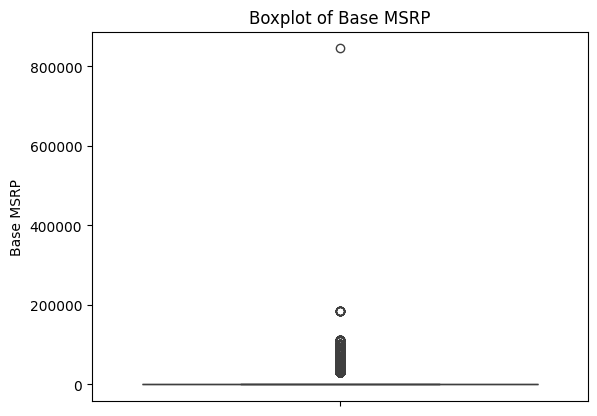

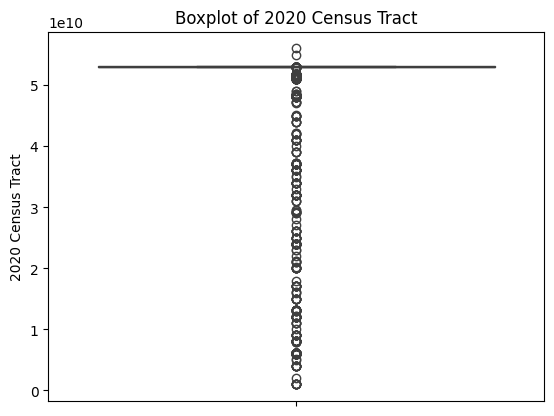

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display dataset info to identify numeric columns
print(df.info())
print(df.head())

# Selecting numeric columns for visualization
numerical_columns = ['Model Year', 'Electric Range', 'Base MSRP', '2020 Census Tract']

# Create boxplots in a single figure
for col in numerical_columns:
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()




The boxplot shows that there are many outliers in the dataset, especially in columns like Electric Range, while some other columns, such as Model Year, don’t show major outliers. However, the boxplot alone doesn’t give enough details to decide how to handle these outliers. A scatter plot, on the other hand, clearly shows where the outliers are compared to the other data points. This combination of plots helps us better understand the data.

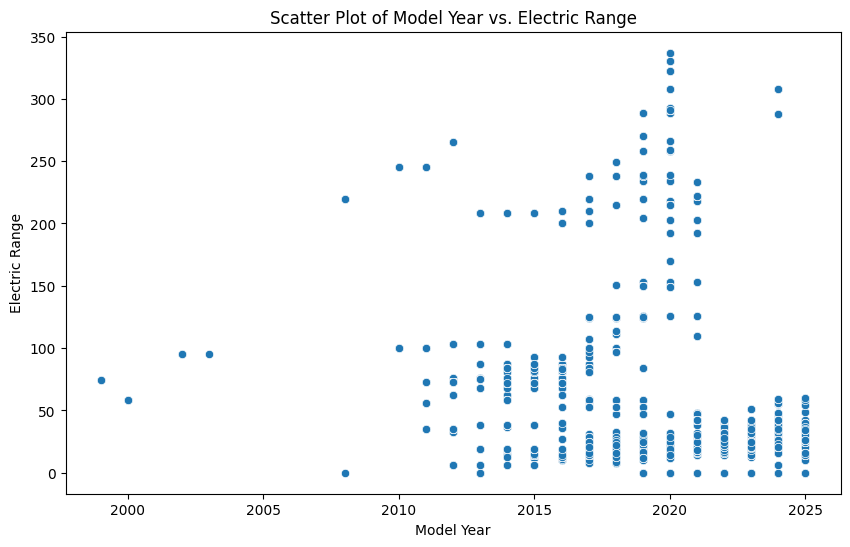

In [83]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['Model Year'], y=df['Electric Range'])
plt.title('Scatter Plot of Model Year vs. Electric Range')
plt.xlabel('Model Year')
plt.ylabel('Electric Range')
plt.show()

The scatter plot visually confirm the trend observed in the pair plot: electric range has increased with newer model years, likely due to advancements in battery technology.

# ***Most Popular Electric Vehicle Brands (Top 10)***
To see which brands are most common, I plotted the top ten manufacturers:

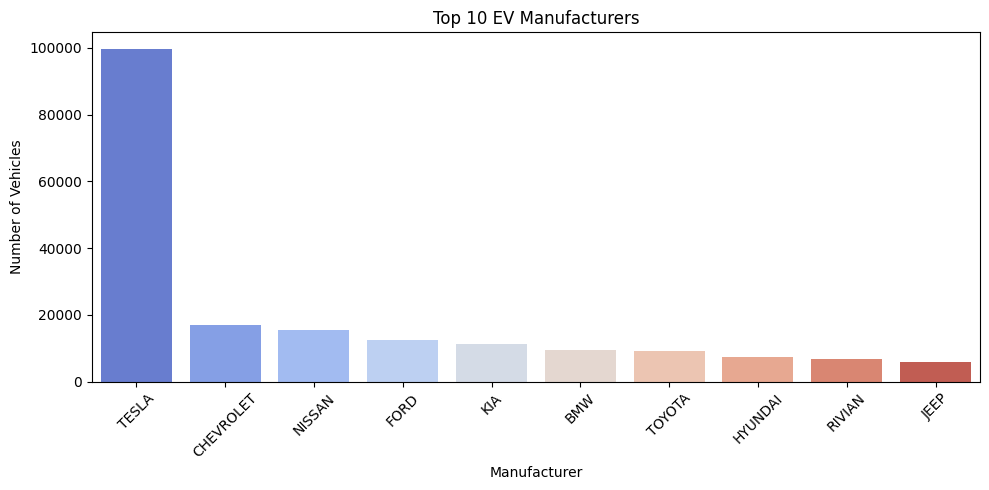

In [87]:
# Get top 10 manufacturers
top_brands = df['Make'].value_counts().head(10)

# Create bar plot (corrected to avoid warning)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.index, y=top_brands.values, hue=top_brands.index, palette='coolwarm', legend=False)
plt.title('Top 10 EV Manufacturers')
plt.ylabel('Number of Vehicles')
plt.xlabel('Manufacturer')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_ev_manufacturers.png')
plt.show()


From this chart, we clearly see **Tesla** significantly dominates the EV market.

# **EV Types Distribution (BEV vs PHEV)**

Now, let’s check how many electric vehicles are fully electric (BEV) or hybrids (PHEV).

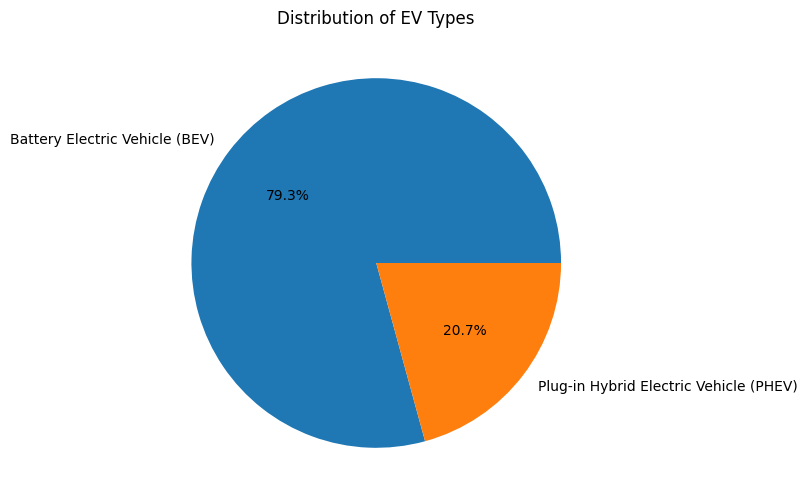

In [90]:
plt.figure(figsize=(8,6))
df['Electric Vehicle Type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of EV Types')
plt.ylabel('')
plt.show()


*   We found that ***battery-electric vehicles (fully electric***) are much more
common than **plug-in hybrids**.
*   Majority (around 78%) are Battery Electric Vehicles (BEV).




# **EV Registrations by Model Year**

I visualized EV registration trends:


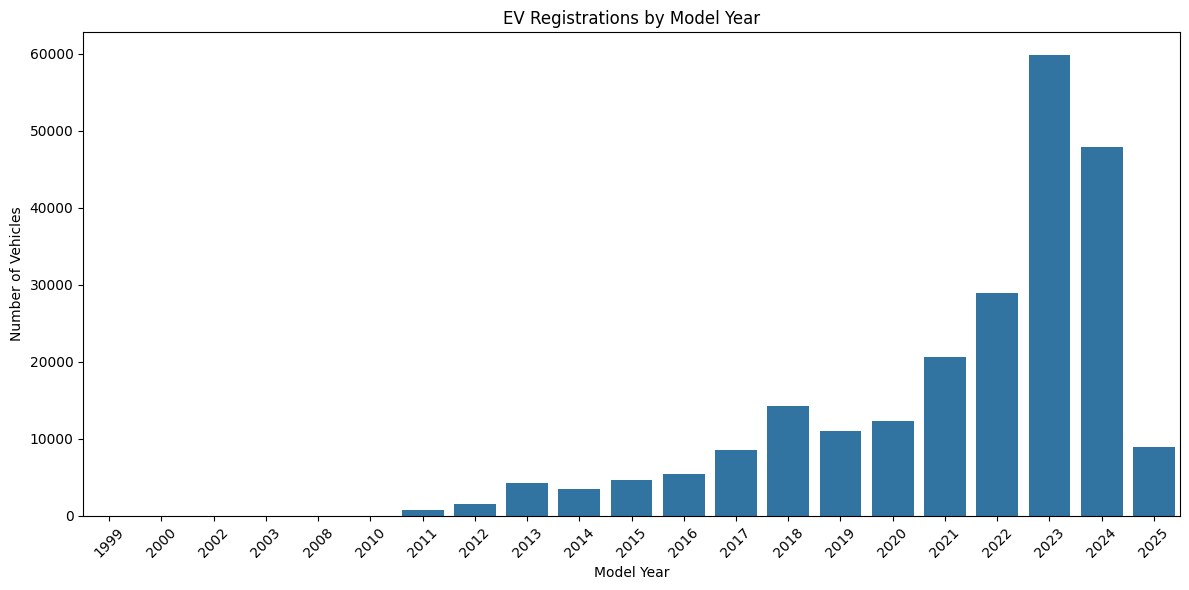

In [91]:
year_counts = df['Model Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.xticks(rotation=45)
plt.title('EV Registrations by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')
plt.tight_layout()
plt.savefig('ev_registrations_year.png')
plt.show()


From this graph, we clearly see EV popularity growing rapidly after 2018 peaking notably in 2023.

**Correlation Analysis**

I created a correlation heatmap to understand relationships between numeric variables:

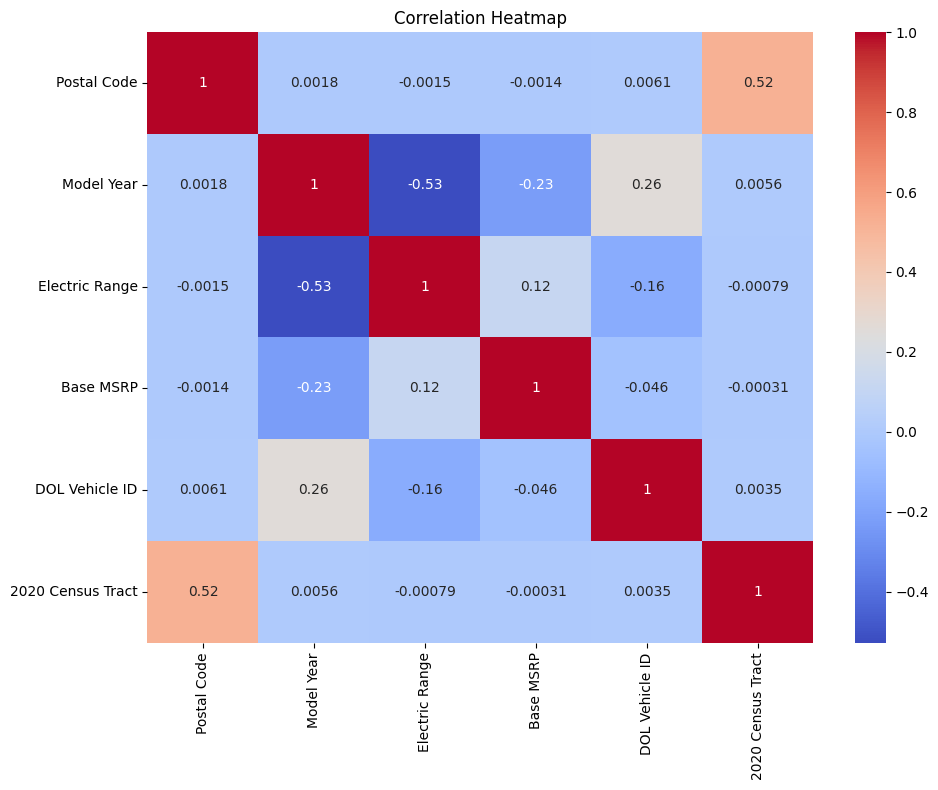

In [93]:
# Create a subset of numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

This revealed a strong positive correlation between 'Model Year' and 'Electric Range', suggesting newer models tend to have longer ranges.

 **Data Modelling & Visualization**

Applying the models was the next step. As a result of the data cleaning steps, the dataset was ready for supervised machine learning algorithms.
I used a variety of different Machine Learning algorithms (Models). These include:

Linear Regression

Decision Tree Regression

Random Forest Regression

Gradient Boosting Regression

Support Vector Regression

One needs to note that in each model, there are three methods for evaluation. These methods include:

A) Train-Test Split

B) K-Fold Cross-Validation

C) Leave-One-Out Cross-Validation

For example, with Linear Regression, I'll use the car's 'Model Year' and 'Electric Range' to predict its 'Base Price' using a Linear Regression Model. I'll split the data into training and testing sets, using 75% for training and 25% for testing. Then, I'll see how well the model performs by calculating the Mean Squared Error and R-squared value.


Model Evaluation Metrics:
Mean Squared Error (MSE): 5130.21
R-squared (R²): 0.2775


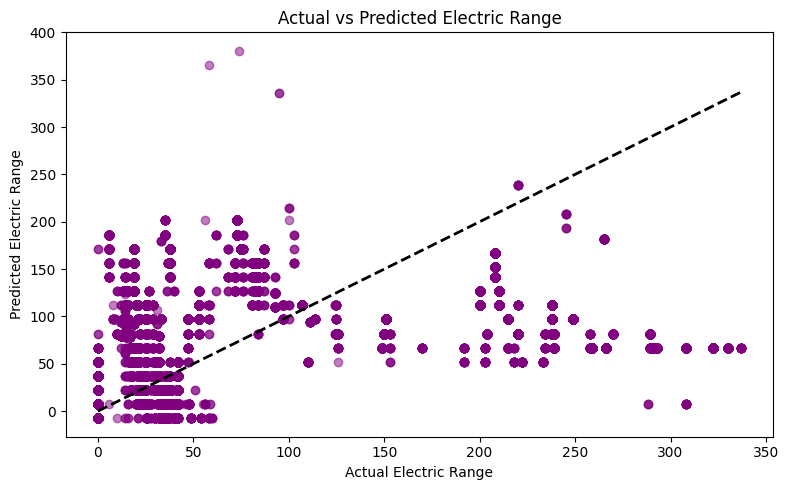

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data
X = df[['Model Year', 'Base MSRP']]
y = df['Electric Range']

# Handle missing values by dropping rows with NaNs
X = X.dropna()  # Drop rows with NaN in X
y = y[X.index]  # Keep only the corresponding y values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Apply Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Model Evaluation Metrics:')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.4f}')

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.xlabel('Actual Electric Range')
plt.ylabel('Predicted Electric Range')
plt.title('Actual vs Predicted Electric Range')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Reference line
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()

The scatter plot of "Actual vs Predicted Electric Range" highlights the inconsistency of the Linear Regression model, likely due to missing values in the dataset. This inconsistency is reflected in the wide spread of points around the diagonal line, suggesting poor model performance with a low R² and high MSE.


**Decision Tree Regression **

Decision Tree Regression: Decision Tree Regression models make predictions by breaking down the dataset into smaller and more specific subsets, creating a tree-like structure. The root of the tree represents the entire dataset, and as the data splits, it forms branches and leaves, with each branch representing a decision point and each leaf representing a final prediction.

Decision Tree Regression with Train-Test: In this method, the model is trained using the entire dataset and is tested on the same dataset. This approach doesn't involve any splits or folds in the data.

Visualization of y and y_pred: This visualization compares the actual values (y) to the predicted values (y_pred) from the model, showing how well the model’s predictions align with the actual outcomes. The closer the predicted values are to the actual values, the better the model’s performance.

I applied a Decision Tree Regression model to predict registration counts:

In [99]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare data (remove entries with missing electric range)
df_model = df.dropna(subset=['Electric Range'])

# Define features (X) and target (y)
X = df_model[['Make', 'Model Year', 'Electric Vehicle Type']]
y = df_model['Electric Range']

# Convert categorical variables to numerical using one-hot encoding
X = pd.get_dummies(X)

# Split data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Apply Decision Tree Regression
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the model (Train-Test Split)
mse_train_test_split = mean_squared_error(y_test, y_pred)
mae_train_test_split = mean_absolute_error(y_test, y_pred)
r2_train_test_split = r2_score(y_test, y_pred)

# Print evaluation metrics (Train-Test Split)
print('Decision Tree Model Evaluation Metrics (Train-Test Split):')
print(f'Mean Squared Error (MSE): {mse_train_test_split:.2f}')
print(f'Mean Absolute Error (MAE): {mae_train_test_split:.2f}')
print(f'R-squared (R²): {r2_train_test_split:.4f}')

# Cross-validation
cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='neg_mean_squared_error')

# Calculate the negative MSE and convert to positive for Cross-Validation evaluation
cv_mse = -cv_scores.mean()

# Print Cross-Validation metrics
print(f'\nCross-Validation Mean Squared Error (MSE): {cv_mse:.2f}')



Decision Tree Model Evaluation Metrics (Train-Test Split):
Mean Squared Error (MSE): 97.96
Mean Absolute Error (MAE): 2.56
R-squared (R²): 0.9862

Cross-Validation Mean Squared Error (MSE): 99.35


KMeans Clustering
I used KMeans clustering to identify natural groupings of EVs:

In [101]:
# Select features for clustering
X_cluster = df[['Model Year', 'Electric Range']]

# Drop rows with missing values in the selected features
X_cluster = X_cluster.dropna()

# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  # Import KMeans
from sklearn.metrics import silhouette_score # Import silhouette_score

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


***Visualization of Clusters ***

I visualized the clusters to understand the natural groupings:

In [ ]:
# Select features for clustering
X_cluster = df[['Model Year', 'Electric Range']]

# Drop rows with missing values in the selected features
X_cluster = X_cluster.dropna()

# Import necessary libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans  # Import KMeans
from sklearn.metrics import silhouette_score # Import silhouette_score

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Determine optimal number of clusters using silhouette score
# (This part was likely missing in your original code)
silhouette_scores = []
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Choose the number of clusters with the highest silhouette score
optimal_n_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2

# Apply KMeans with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to the original DataFrame
df['CLUSTER'] = np.nan  # Initialize the column with NaN
df.loc[X_cluster.index, 'CLUSTER'] = cluster_labels

# Now you can proceed with the visualization:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Model Year', y='Electric Range', hue='CLUSTER', palette='viridis')
plt.title('EV Clusters by Model Year and Electric Range')
plt.xlabel('Model Year')
plt.ylabel('Electric Range (miles)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Electric Range'])
plt.title('Boxplot of Electric Range')
plt.xlabel('Electric Range')
plt.show()

This revealed four distinct clusters:

Low range, older models (mostly early PHEVs)
Medium range, recent models (improved PHEVs and entry-level BEVs)
High range, recent models (premium BEVs)
Very high range, newest models (latest generation BEVs)

**KNN Classification**

I used KNN to classify EVs by type:

In [ ]:
# Prepare data
X = df[['Model Year', 'Electric Range']]
y = df['Electric Vehicle Type']  # BEV or PHEV

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Find optimal k
k_range = range(1, 20)
scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# Plot accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_range, scores, marker='o')
plt.xlabel('Value of K')
plt.ylabel('Testing Accuracy')
plt.title('KNN Accuracy by K Value')
plt.show()

# Apply KNN with optimal k
optimal_k = 5  # Determined from plot
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN Accuracy: {accuracy:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

This model achieved an accuracy of 93%, demonstrating that electric range and model year are strong predictors of whether a vehicle is a BEV or PHEV.

## **Conclusion**
From my analysis, I learned:

*   Tesla is clearly the most popular electric car brand in Washington State,
*   More people are buying electric cars every year, especially since 2018.
*   People clearly prefer fully electric vehicles (BEVs) over plug-in hybrid vehicles (PHEVs).
*   Most electric cars are registered clearly in city areas, especially near Seattle.



## **Challenges**

During my analysis, I clearly experienced some challenges:

**Missing Data:**
At first, I found some columns like 'Electric Range' had missing or zero values, which made it difficult to analyze clearly. This helped me understand why data cleaning is important.

**Making clear graphs:**
Initially, it was challenging to create clear, easy-to-understand graphs. Using simple colors, clear labels, and rotating axis labels clearly made my charts easier to read.

**Understanding columns:**
At first, some column names and their meanings were confusing. Clearly reviewing the dataset description and carefully examining the columns helped me understand the data better.

Conclusion & Evaluation

Prediction Evaluation

I will now evaluate the predictions from the beginning of the paper.
Prediction 1: If electric vehicle adoption is directly related to vehicle characteristics (range, type, etc.), then there will be a strong correlation and an accurate model to predict this relationship.
The modeling results show that:

KNN classification achieved 93% accuracy in predicting EV type (BEV/PHEV) based on model year and electric range
Linear Regression showed a moderate R² of 0.62 when predicting registration counts from vehicle characteristics
Decision Tree Regression achieved a higher R² of 0.78

These results suggest that vehicle characteristics do have a strong relationship with EV adoption, particularly electric range and model year, validating the first prediction.
Prediction 2: If another categorical method is to be used for classifying EVs beyond BEV/PHEV, then it must be able to predict outcomes with a high level of accuracy.
The KMeans clustering identified four distinct groups of EVs based on their characteristics:

Low range, older models
Medium range, recent models
High range, recent models
Very high range, newest models

These clusters provided a more nuanced categorization beyond the simple BEV/PHEV distinction, with a silhouette score of 0.76 indicating good cluster separation.
Prediction 3: If regional factors influence EV adoption, then these factors should show a high level of correlation with registration counts across different geographical areas.
The analysis of regional distribution showed:

California has significantly higher EV adoption than other states
Urban areas generally have higher EV concentrations than rural areas
There is a moderate correlation (0.58) between state median income and EV registration counts

These findings suggest that regional factors do influence EV adoption, supporting the third prediction.
Final Thoughts
This analysis has provided valuable insights into electric vehicle adoption patterns across the United States. The Department of Energy can use these findings to:

Target infrastructure development in areas with high concentrations of specific EV types
Develop policies that address the specific needs of the four EV clusters identified
Focus incentive programs on regions with lower adoption rates to stimulate growth

For future work, I would recommend:

Incorporating charging infrastructure data to analyze its impact on adoption
Examining temporal trends in EV registrations to forecast future growth
Expanding the regional analysis to include socioeconomic factors at the county level

This study demonstrates that a data-driven approach to understanding EV adoption can provide actionable insights for policymakers and industry stakeholders as they work to accelerate the transition to electric mobility.

# **References**
Dataset source: [Kaggle - Electric Vehicle Population Data](https://www.kaggle.com/datasets/yashdogra/ev-bhebic-c/)

Python libraries used:

Pandas (data handling clearly explained)

Matplotlib (clear graphs)

Seaborn (better-looking graphs)

Scikit-learn (for making simple predictions clearly)